<a href="https://colab.research.google.com/github/agarwalpratik/aiml/blob/main/Automating_Port_Operations_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marina Pier Inc. is leveraging technology to automate their operations on the San Francisco port.
The company’s management has set out to build a bias-free/ corruption-free automatic system that reports & avoids faulty situations caused by human error. Examples of human error include misclassifying the correct type of boat. The type of boat that enters the port region is as follows.

●	Buoy

●	Cruise_ship

●	Ferry_boat

●	Freight_boar

●	Gondola

●	Inflatable_boat

●	Kayak

●	Paper_boat

●	Sailboat


Marina Pier wants to use Deep Learning techniques to build an automatic reporting system that recognizes the boat. The company is also looking to use a transfer learning approach of any lightweight pre-trained model in order to deploy in mobile devices.
As a deep learning engineer, your task is to:

1.	Build a CNN network to classify the boat.

2.	Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.


Perform the following steps:

1.	Build a CNN network to classify the boat.

1.1.	Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.

1.2.	Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization.
(Hint: image_scale=1./255).

1.3.	Load train, validation and test dataset in batches of 32 using the function initialized in the above step.

1.4.	Build a CNN network using Keras with the following layers

•	Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D

•	Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D

•	GLobalAveragePooling2D layer

•	Dense layer with 128 neurons and activation relu

•	Dense layer with 128 neurons and activation relu

•	Dense layer with 9 neurons and activation softmax.

1.5.	Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.

1.6.	Train the model for 20 epochs and plot training loss and accuracy against epochs.

1.7.	Evaluate the model on test images and print the test loss and accuracy.

1.8.	Plot heatmap of the confusion matrix and print classification report.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.__version__

'2.17.1'

In [ ]:
#Extract the Zip File

!unzip boat_type_classification_dataset.zip


Archive:  boat_type_classification_dataset.zip
   creating: boat_type_classification_dataset/
   creating: boat_type_classification_dataset/buoy/
  inflating: boat_type_classification_dataset/buoy/1.jpg  
  inflating: boat_type_classification_dataset/buoy/10.jpg  
  inflating: boat_type_classification_dataset/buoy/11.jpg  
  inflating: boat_type_classification_dataset/buoy/12.jpg  
  inflating: boat_type_classification_dataset/buoy/13.jpg  
  inflating: boat_type_classification_dataset/buoy/14.jpg  
  inflating: boat_type_classification_dataset/buoy/15.jpg  
  inflating: boat_type_classification_dataset/buoy/16.jpg  
  inflating: boat_type_classification_dataset/buoy/17.jpg  
  inflating: boat_type_classification_dataset/buoy/18.jpg  
  inflating: boat_type_classification_dataset/buoy/19.jpg  
  inflating: boat_type_classification_dataset/buoy/2.jpg  
  inflating: boat_type_classification_dataset/buoy/20.jpg  
  inflating: boat_type_classification_dataset/buoy/21.jpg  
  inflating: boa

In [3]:
#1.1.	Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.
#1.2.	Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization.
#(Hint: image_scale=1./255).
#1.3.	Load train, validation and test dataset in batches of 32 using the function initialized in the above step.

my_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0,
                                                               validation_split=0.2)

trainImageData = my_generator.flow_from_directory('boat_type_classification_dataset',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='training')

testImageData = my_generator.flow_from_directory('boat_type_classification_dataset',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='validation')

Found 934 images belonging to 9 classes.
Found 228 images belonging to 9 classes.


1.4.	Build a CNN network using Keras with the following layers

•	Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D

•	Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D

•	GLobalAveragePooling2D layer

•	Dense layer with 128 neurons and activation relu

•	Dense layer with 128 neurons and activation relu

•	Dense layer with 9 neurons and activation softmax.

In [4]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=trainImageData.image_shape , padding='same'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu",padding='same'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

model.add(tf.keras.layers.Dense(units=9, activation='softmax'))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,041 (125.16 KB)

 Trainable params: 32,041 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#1.5.	Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

In [7]:
class MyCLRuleMonitor(tf.keras.callbacks.Callback):
  def __init__(self, CL):
    super(MyCLRuleMonitor).__init__()
    self.CL = CL

  def on_epoch_end(self, epoch, logs=None):
    trainScore = logs["accuracy"]
    testScore = logs["val_accuracy"]

    if testScore > trainScore and testScore >= self.CL:
      self.model.stop_training = True

In [8]:
#1.6.	Train the model for 20 epochs and plot training loss and accuracy against epochs.

history = model.fit(trainImageData,
          validation_data=testImageData,
          epochs=20,
          steps_per_epoch=(len(trainImageData.filenames) // trainImageData.batch_size - 1),
          validation_steps=(len(testImageData.filenames) // testImageData.batch_size - 1 ),
          callbacks=[MyCLRuleMonitor(0.7)])

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.2006 - loss: 2.1082 - precision: 0.2029 - recall: 0.0040 - val_accuracy: 0.3333 - val_loss: 1.8371 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2360 - loss: 1.9046 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3611 - val_loss: 1.6232 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 379ms/step - accuracy: 0.3363 - loss: 1.8560 - precision: 0.4714 - recall: 0.0048 - val_accuracy: 0.3281 - val_loss: 1.8007 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4213 - loss: 1.7484 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3611 - val_loss: 1.8039 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 357ms/step - accuracy: 0.3232 - loss: 1.8001 - precision: 0.4546 - recall: 0.0072 - val_accuracy: 0.3438 - val_loss: 1.7728 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3772 - loss: 1.9506 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3611 - val_loss: 1.8332 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 381ms/step - accuracy: 0.3235 - loss: 1.7658 - precision: 0.4149 - recall: 0.0053 

In [9]:
#Deploy Example
model

<Sequential name=sequential, built=True>

In [14]:
img = tf.keras.preprocessing.image.load_img('boat_type_classification_dataset/kayak/10.jpg', target_size=(64,64))

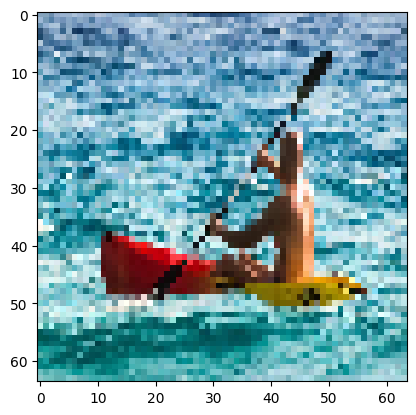

In [15]:
+
import matplotlib.pyplot as plt
plt.imshow(img)

In [16]:
imgArray= tf.keras.preprocessing.image.img_to_array(img)
compatibleArray = np.expand_dims(imgArray, axis=0)

In [17]:
{v:k for k,v in trainImageData.class_indices.items()} [ np.argmax(model.predict(compatibleArray)) ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


'sailboat'

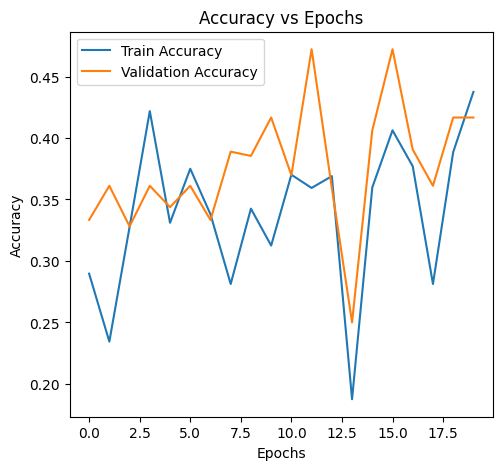

In [18]:
#1.7.	Evaluate the model on test images and print the test loss and accuracy.

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

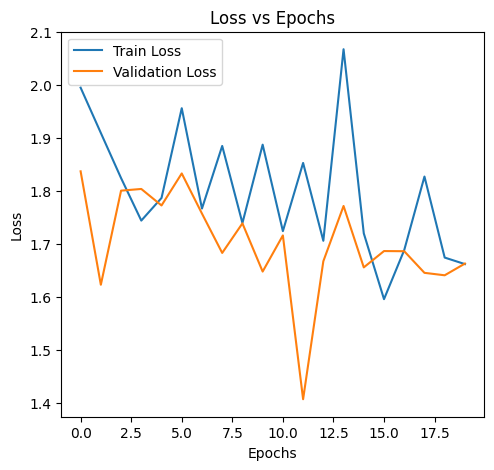

In [19]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step


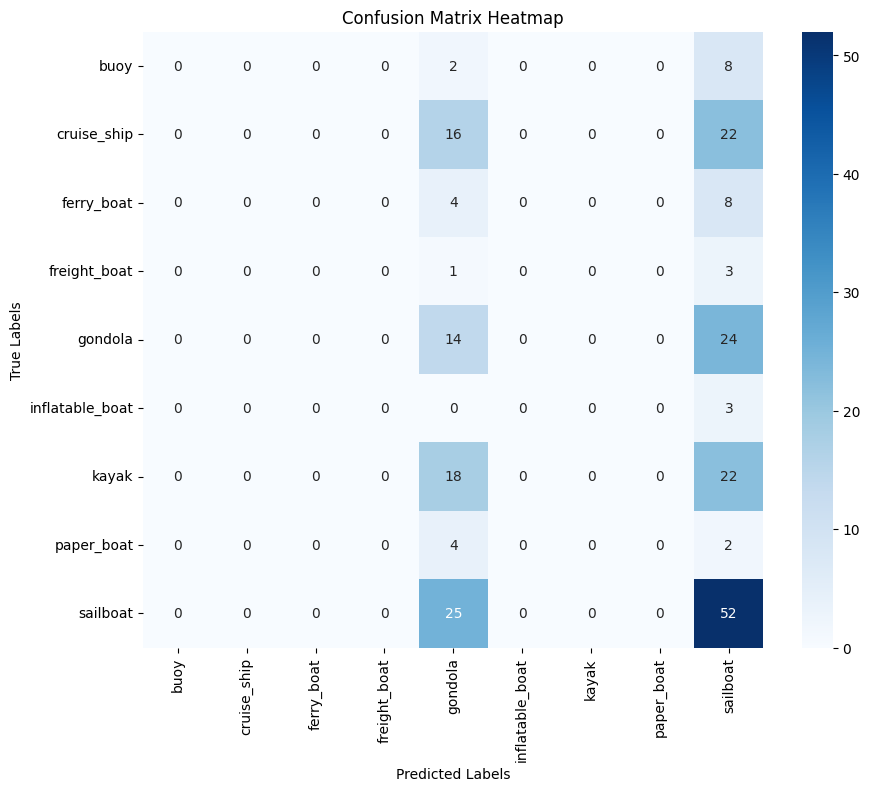

Classification Report:

                 precision    recall  f1-score   support

           buoy       0.00      0.00      0.00        10
    cruise_ship       0.00      0.00      0.00        38
     ferry_boat       0.00      0.00      0.00        12
   freight_boat       0.00      0.00      0.00         4
        gondola       0.17      0.37      0.23        38
inflatable_boat       0.00      0.00      0.00         3
          kayak       0.00      0.00      0.00        40
     paper_boat       0.00      0.00      0.00         6
       sailboat       0.36      0.68      0.47        77

       accuracy                           0.29       228
      macro avg       0.06      0.12      0.08       228
   weighted avg       0.15      0.29      0.20       228



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
# 1.8 Plot heatmap of the confusion matrix and print classification report.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Number of samples in the test dataset
test_steps = testImageData.samples // testImageData.batch_size
if testImageData.samples % testImageData.batch_size != 0:
    test_steps += 1  # Include the last incomplete batch if it exists

# Generate predictions
y_pred_prob = model.predict(testImageData, steps=test_steps, verbose=1)

# Align the predicted and true labels
y_pred = np.argmax(y_pred_prob, axis=1)  # Predicted class indices
y_true = testImageData.classes[:len(y_pred)]  # True labels aligned with predictions

# Get class labels (mapping of indices to class names)
class_labels = list(testImageData.class_indices.keys())

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))
